# Conceptual

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

## Q1.
```{admonition}
:class: note
It was mentioned in this chapter that a cubic regression spline with one knot at $\xi$ can be obtained using a basis of the form $x, x^{2}, x^{3}, (x − \xi)^{3}_{+}$, where $(x − \xi)^{3}_{+} = \operatorname{max}(x-\xi,0)^{3}$.
    
We will now show that a function of the form
$$
f(x) = \beta_{0}+\beta_{1}x+\beta_{2}x^{2}+\beta_{3}x^{3}+\beta_{4}(x − \xi)^{3}_{+}
$$
is indeed a cubic regression spline, regardless of the values of $\beta_{i}$.

```{admonition}
:class: note
(a+b) Show $f$ is a piecewise polynomial.

If $x\leq\xi$, then $f(x) = \beta_{0}+\beta_{1}x+\beta_{2}x^{2}+\beta_{3}x^{3}$, a cubic polynomial. If $x > \xi$, then $f(x) = \beta_{0}+\beta_{1}x+\beta_{2}x^{2}+\beta_{3}x^{3}+\beta_{4}(x − \xi)^{3}$, which is again a polynomial.

```{admonition}
:class: note
(c+d+e) Show that $f\in C^{2}$.

First note $f(x) = g(x)+\beta_{4}(x − \xi)^{3}_{+}$, where $g$ is a polynomial. Next, we consider $h(x) = (x − \xi)^{3}_{+}$. Note that $h$ can be written piecewise as
$$
h(x) = 
\begin{cases}
0 & x \leq \xi\\
(x-\xi)^{3} & x > \xi
\end{cases}
$$
and the derivatives can be found by computing one sided derivatives. The left derivatives are always 0, and the two right derivatives are $3(x-\xi)^{2}$ and $6(x-\xi)$. Taking the appropriate directional limits, we see the right derivatives equal 0 and therefore $h$ is $C^{2}$. Returning to $f = g+h$, this is the sum of a $C^{\infty}$ and $C^{2}$ function so must be $C^{2}$.

## Q2.
```{admonition}
:class: note
Suppose that a curve $\hat{g}$ is computed to smoothly fit a set of $n$ points using the following formula:
$$
\hat{g} = \operatorname*{arg\,min}_{g}\left(\sum_{i=1}^{n}(y_{i}-g(x_{i}))^{2}+\lambda\int (g^{(m)}(x))^{2}\operatorname{d}x\right).
$$

Provide example sketches of $\hat{g}$ in each of the following scenarios.

In [198]:
rng = np.random.default_rng(1729)
xs = np.linspace(-3.1,3.1,1000)
xis = np.arange(-3,4)
yis = 1+0.5*xis+rng.normal(size = 7,scale=0.5)

```{admonition}
:class: note
(a) $\lambda = \infty, m = 0$.

Need $g = 0$.

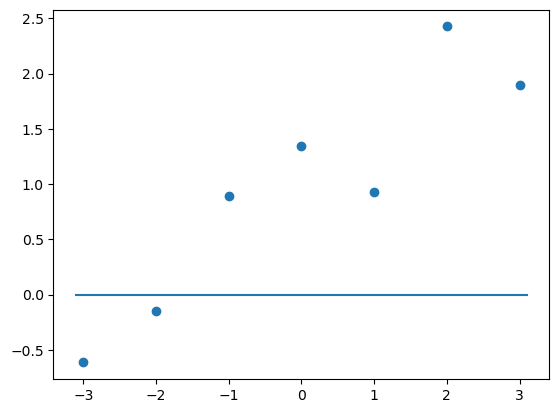

In [199]:
plt.plot(xs,np.zeros(len(xs)))
plt.scatter(xis,yis)
plt.show()

```{admonition}
:class: note
(b) $\lambda = \infty, m = 1$.

Need $g' = 0 \to g = c$ least squares, i.e. $g=\overline{y}$.

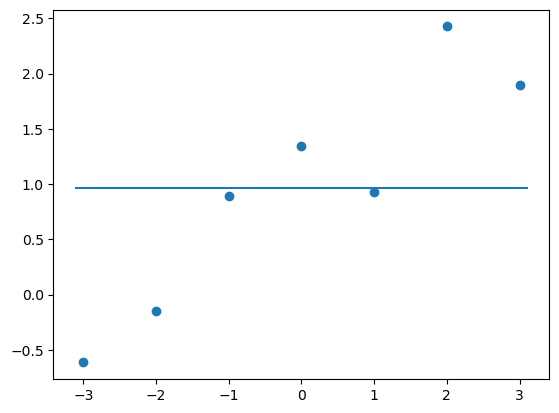

In [200]:
plt.plot(xs,np.ones(len(xs))*np.mean(yis))
plt.scatter(xis,yis)
plt.show()

```{admonition}
:class: note
(c) $\lambda = \infty, m = 2$.

Need $g'' = 0 \to g = cx+d$ least squares.

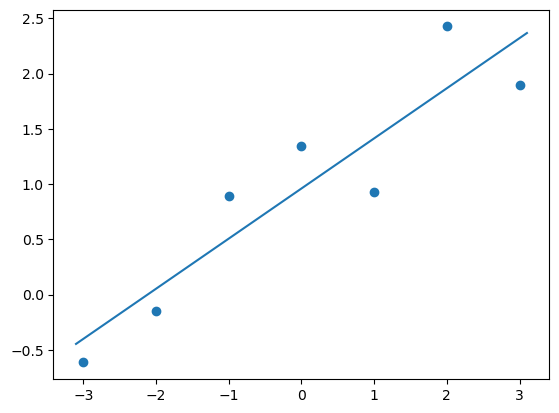

In [201]:
lr = LinearRegression().fit(xis.reshape(-1,1),yis)
ys = lr.predict(xs.reshape(-1,1))
plt.plot(xs,ys)
plt.scatter(xis,yis)
plt.show()

```{admonition}
:class: note
(d) $\lambda = \infty, m = 3$.

Need $g''' = 0 \to g = cx^{2}+dx+e$ least squares quadratic fit.

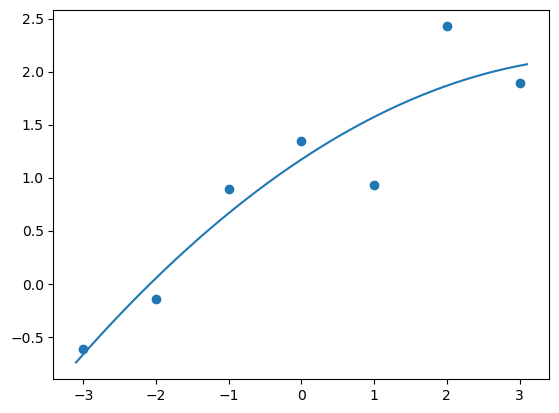

In [202]:
lr = LinearRegression().fit(np.column_stack([xis,xis**2]),yis)
ys = lr.predict(np.column_stack([xs,xs**2]))
plt.plot(xs,ys)
plt.scatter(xis,yis)
plt.show()

```{admonition}
:class: note
(e) $\lambda = 0, m = 3$.

No additional $g$ restriction $\to$ perfect interpolation (non-unique).

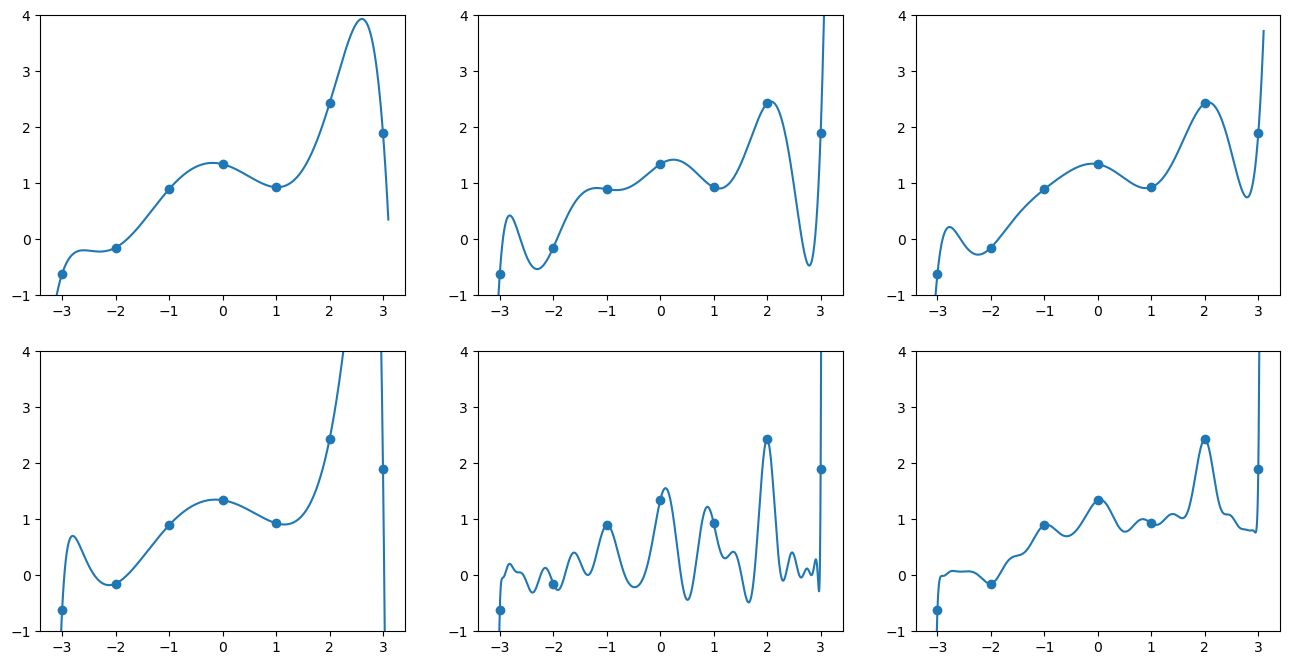

In [203]:
import warnings
fig, ax = plt.subplots(2,3,figsize=(16,8))
ax = ax.flatten()
for axis in ax:
    axis.scatter(xis,yis)
    axis.set_ylim(-1,4)
with warnings.catch_warnings():
    warnings.filterwarnings('ignore','The fit')
    ax[0].plot(xs,np.polynomial.Polynomial.fit(xis,yis,8)(xs))
    ax[3].plot(xs,np.polynomial.Polynomial.fit(xis,yis,30)(xs))
    ax[1].plot(xs,np.polynomial.Chebyshev.fit(xis,yis,10)(xs))
    ax[4].plot(xs,np.polynomial.Chebyshev.fit(xis,yis,30)(xs))
    ax[2].plot(xs,np.polynomial.Legendre.fit(xis,yis,10)(xs))
    ax[5].plot(xs,np.polynomial.Legendre.fit(xis,yis,30)(xs))

## Q3.
```{admonition}
:class: note
Suppose we fit a curve with basis functions $b_{1}(X) = X$, $b_{2}(X) = (X-1)^{2}[X\geq 1]$. We fit the linear regression model
$$
Y = \beta_{0}+\beta_{1}b_{1}(X)+\beta_{2}(X)+\varepsilon
$$
and obtain coefficient estimates $\hat{\beta}_{0} = 1$, $\hat{\beta}_{1} = 1$, $\hat{\beta}_{2} = -2$. Sketch the estimated curve between $X = -2$ and $X = 2$.

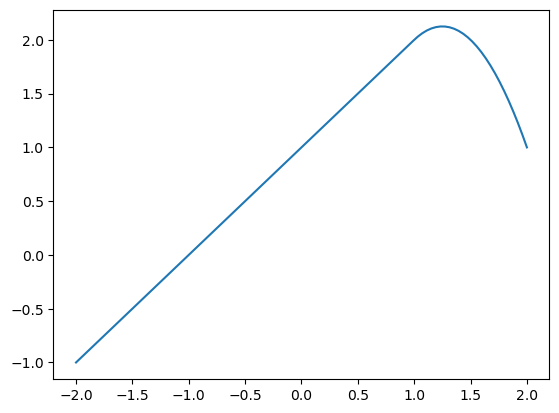

In [207]:
xs = np.linspace(-2,2,100)
ys = 1+1*xs-2*(xs-1)**2*(xs >= 1)
plt.plot(xs,ys)
plt.show()

## Q4.
```{admonition}
:class: note
Suppose we fit a curve with basis functions $b_{1}(X) = [0\leq X \leq 2]-(X-1)[1\leq x \leq 2]$, $b_{2}(X) = (X-3)[3\leq x \leq 4]+[4 < x \leq 5]$. We fit the linear regression model
$$
Y = \beta_{0}+\beta_{1}b_{1}(X)+\beta_{2}(X)+\varepsilon
$$
and obtain coefficient estimates $\hat{\beta}_{0} = 1$, $\hat{\beta}_{1} = 1$, $\hat{\beta}_{2} = 3$. Sketch the estimated curve between $X = -2$ and $X = 6$.

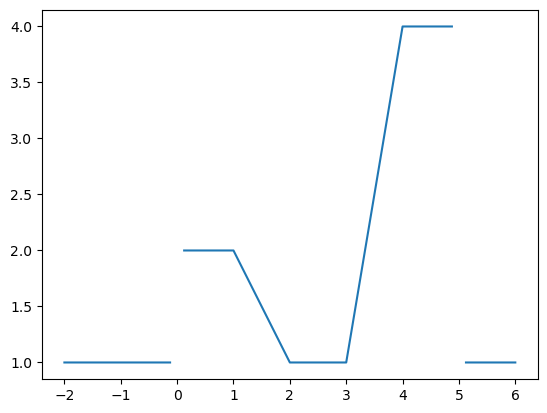

In [242]:
xs = np.linspace(-2,6,65)
b1s = ((0 <= xs) & (xs <= 2))-(xs-1)*((1 <= xs) & (xs <= 2))
b2s = (xs-3)*((3 <= xs) & (xs <= 4))+((4 < xs) & (xs <= 5))
ys = 1+1*b1s+3*b2s
jump = np.isin(xs,[0,5])
ys = np.where(jump, np.nan, ys)
plt.plot(xs,ys)
plt.show()

## Q5.
```{admonition}
:class: note
Consider two curves $\hat{g}_{1}$ and $\hat{g}_{2}$ defined by
$$
\hat{g}_{j} = \operatorname*{arg\,min}_{g}\left(\sum_{i=1}^{n}(y_{i}-g(x_{i}))^{2}+\lambda\int (g^{(2+j)}(x))^{2}\operatorname{d}x\right).
$$

```{admonition}
:class: note
(a) As $\lambda \to \infty$ will $\hat{g}_{1}$ or $\hat{g}_{2}$ have smaller training RSS?

As $\lambda$ increases, $\hat{g}_{1}$ becomes quadratic and $\hat{g}_{2}$ becomes cubic. The cubic model is more flexible and contains the quadratic model, so will have smaller training RSS.

```{admonition}
:class: note
(b) As $\lambda \to \infty$ will $\hat{g}_{1}$ or $\hat{g}_{2}$ have smaller test RSS?

Depending on the underlying data, either could have a smaller test RSS. If the data is cubic, then $\hat{g}_{2}$ will likely improve over $\hat{g}_{1}$; however, if the data was quadratic, then $\hat{g}_{2}$ could overfit and perform worse.

```{admonition}
:class: note
(c) For $\lambda = 0$ will $\hat{g}_{1}$ or $\hat{g}_{2}$ have smaller training and test RSS?

The restriction on $g_{1}$ and $g_{2}$ are identical as curves that interpolate the data, so they both have 0 training RSS. Assuming they also use the same choice of interpolation, they will form the same model and have identical training RSS. If the final choice is different, say they fit to a sufficiently high degree polynomial where $g_{1}$ also minimizes $\lVert g_{1}\rVert_{1}$ and $g_{2}$ minimizes $\lVert g_{2}\rVert_{2}$, then the training error can vary between the two.